# Name - Satyam Kale
# Real-Time Bitcoin Price Trend Analysis using Stable-Baselines3

This notebook presents an end-to-end implementation of a reinforcement learning (RL) system designed to predict and respond to Bitcoin price movements. The core aim is to simulate a trading strategy using historical price data and train an RL agent to learn optimal buy/sell/hold decisions.

---

## Objectives

- Ingest and preprocess 30-day historical Bitcoin price data using the CoinGecko API.
- Build a custom Gymnasium environment (`BitcoinTradingEnv`) that simulates a trading scenario with portfolio tracking.
- Train a Proximal Policy Optimization (PPO) agent from Stable-Baselines3 on normalized price data.
- Evaluate agent performance via visual and quantitative metrics.

---

## Workflow Breakdown

1. **Data Loading and Normalization**
   - Load `bitcoin_historical.csv`, which contains 30 days of hourly BTC/USD prices.
   - Normalize price using z-score transformation to stabilize model inputs.

2. **Environment Setup**
   - The Gymnasium environment is initialized with a rolling window of price data.
   - The agent receives rewards based on profit earned from simulated trades.

3. **Model Training**
   - PPO agent is trained using `MlpPolicy` for 10,000 timesteps.
   - Observed improvement in reward signals over time (`ep_rew_mean`).

4. **Evaluation and Visualization**
   - Actions (Buy, Sell, Hold) are plotted over the actual price curve.
   - Portfolio value and profits are tracked over time.
   - Insights are drawn about learned trading patterns.

---

## Libraries and Tools Used

- Stable-Baselines3 – PPO reinforcement learning algorithm
- Gymnasium – Custom RL environment and simulation
- CoinGecko API – Historical and real-time Bitcoin prices
- Matplotlib, Pandas, Numpy – Data manipulation and visualization



In [1]:
pip install stable_baselines3

Note: you may need to restart the kernel to use updated packages.


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 710      |
|    ep_rew_mean     | 8.92e+03 |
| time/              |          |
|    fps             | 592      |
|    iterations      | 1        |
|    time_elapsed    | 3        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 710         |
|    ep_rew_mean          | 6.59e+03    |
| time/                   |             |
|    fps                  | 499         |
|    iterations           | 2           |
|    time_elapsed         | 8           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.004841864 |
|    clip_fraction        | 0.0116      |
|    clip_range           | 0.2         |
|    entropy_loss   

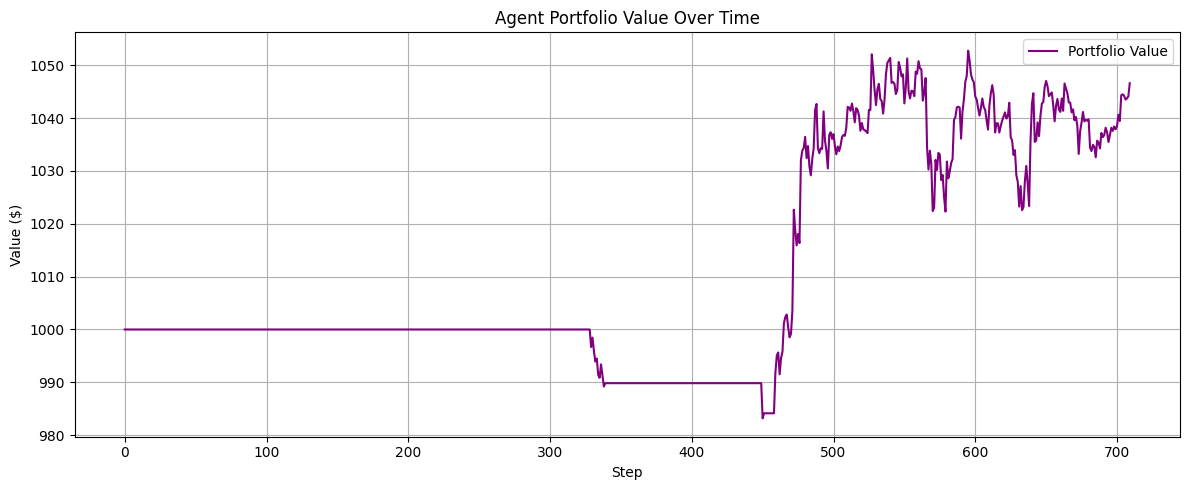

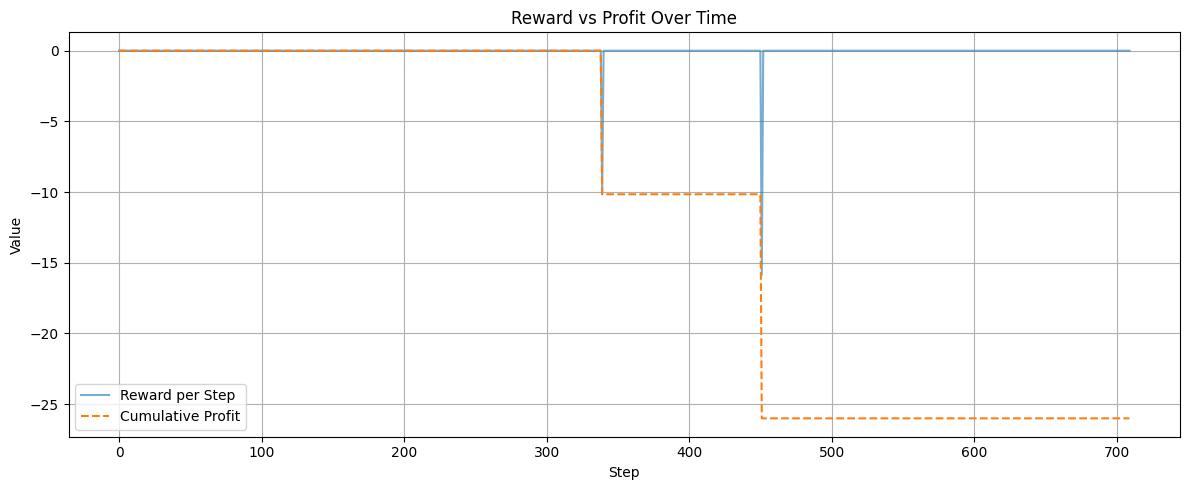

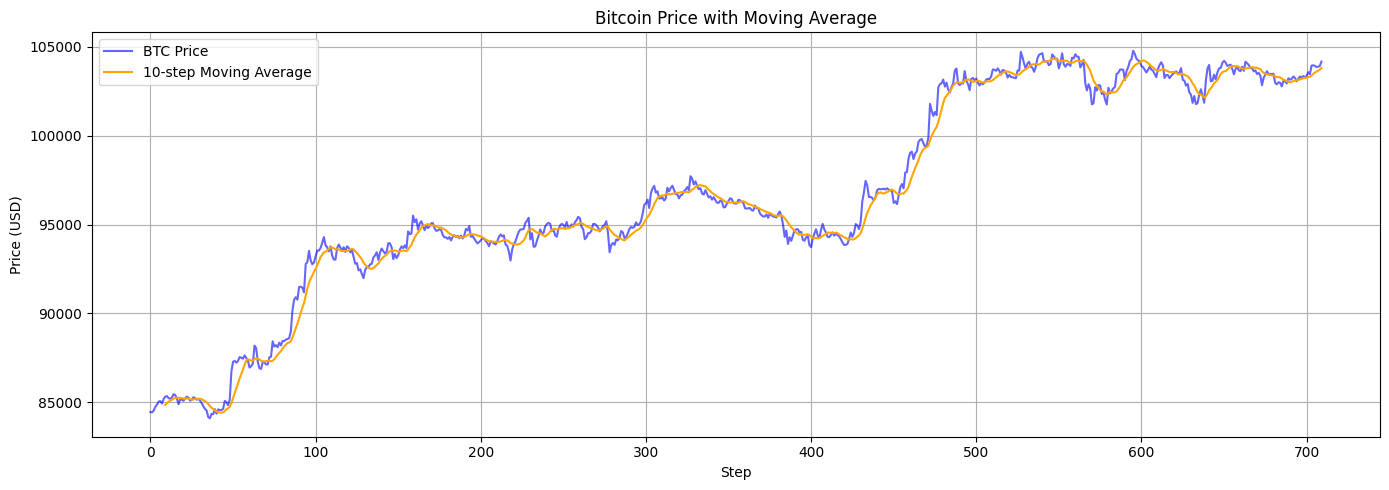

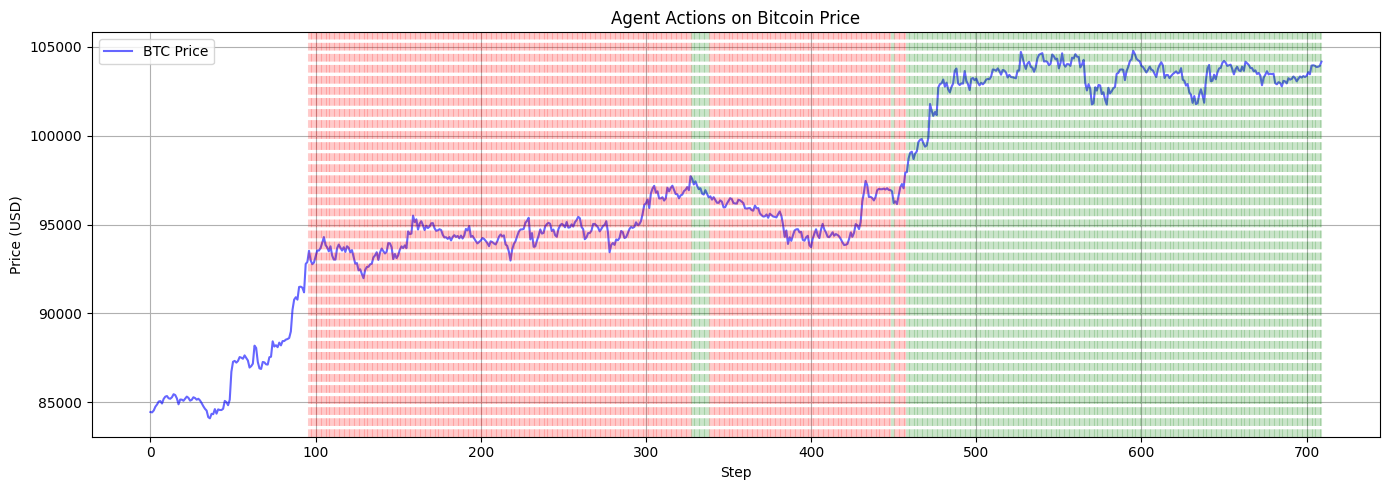


📈 Agent’s predicted next action: Buy
✅ Model saved as 'ppo_bitcoin_trading.zip'


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from stable_baselines3 import PPO
from stablebaseline3_utils import (
    fetch_historical_prices,
    normalize_prices,
    BitcoinTradingEnv
)

# Load BTC price data
df = pd.read_csv("bitcoin_historical.csv", index_col="timestamp", parse_dates=True)
df = df.reset_index()
window_size = 10

# Create and train the environment
env = BitcoinTradingEnv(price_series=df, window_size=window_size)
model = PPO("MlpPolicy", env, verbose=1)
model.learn(total_timesteps=10000)

# Evaluate model + log actions
test_env = BitcoinTradingEnv(price_series=df, window_size=window_size)
obs, _ = test_env.reset()
rewards, profits, actions, portfolio = [], [], [], []

while True:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, _ = test_env.step(action)
    done = terminated or truncated

    rewards.append(reward)
    profits.append(test_env.total_profit)
    actions.append(int(action))  # ✅ Fix: cast to int
    net_worth = test_env.balance + test_env.shares_held * df["price"].iloc[test_env.current_step - 1]
    portfolio.append(net_worth)

    if done:
        break

print(f"✅ Final Profit: ${test_env.total_profit:.2f}")

# 📊 Action Counts
action_counts = Counter(actions)
print("\nAgent Action Counts:")
for act, count in action_counts.items():
    label = {0: "Hold", 1: "Buy", 2: "Sell"}[act]
    print(f"{label}: {count} actions")

# 📈 Portfolio Value Over Time
plt.figure(figsize=(12, 5))
plt.plot(portfolio, label="Portfolio Value", color='purple')
plt.title("Agent Portfolio Value Over Time")
plt.xlabel("Step")
plt.ylabel("Value ($)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 📉 Reward vs Profit
plt.figure(figsize=(12, 5))
plt.plot(rewards, label="Reward per Step", alpha=0.6)
plt.plot(profits, label="Cumulative Profit", linestyle='--')
plt.title("Reward vs Profit Over Time")
plt.xlabel("Step")
plt.ylabel("Value")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 📊 BTC Price with Moving Average
btc_plot = df["price"].values[window_size:]
rolling_mean = pd.Series(btc_plot).rolling(window=10).mean()

plt.figure(figsize=(14, 5))
plt.plot(btc_plot, label="BTC Price", color="blue", alpha=0.6)
plt.plot(rolling_mean, label="10-step Moving Average", color="orange")
plt.title("Bitcoin Price with Moving Average")
plt.xlabel("Step")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 📍 Agent Action Overlay on BTC Price
plt.figure(figsize=(14, 5))
plt.plot(btc_plot, label="BTC Price", color="blue", alpha=0.6)

for i, action in enumerate(actions):
    if action == 1:
        plt.axvline(x=i, color='green', linestyle='--', alpha=0.2, label='Buy' if i == 0 else "")
    elif action == 2:
        plt.axvline(x=i, color='red', linestyle='--', alpha=0.2, label='Sell' if i == 0 else "")

plt.title("Agent Actions on Bitcoin Price")
plt.xlabel("Step")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# 📡 Predict Next BTC Trend Action (in live setting)
latest_window = df["norm_price"].values[-window_size:]
obs = latest_window.astype(np.float32).reshape(1, -1)
predicted_action, _ = model.predict(obs)

action_label = {0: "Hold", 1: "Buy", 2: "Sell"}[int(predicted_action[0])]
print(f"\n📈 Agent’s predicted next action: {action_label}")

# 💾 Save the model
model.save("ppo_bitcoin_trading")
print("✅ Model saved as 'ppo_bitcoin_trading.zip'")


In [3]:
df = fetch_historical_prices(days=60)
df = normalize_prices(df)

train_df = df.iloc[:24*30]
test_df = df.iloc[24*30:]

train_env = BitcoinTradingEnv(price_series=train_df, window_size=10)
test_env = BitcoinTradingEnv(price_series=test_df, window_size=10)

In [4]:
model = PPO("MlpPolicy", train_env, verbose=1)
model.learn(total_timesteps=10000)

# For evaluation
obs, _ = test_env.reset()
# ...
# Use test_env in evaluation loop instead of env


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 710       |
|    ep_rew_mean     | -3.56e+03 |
| time/              |           |
|    fps             | 596       |
|    iterations      | 1         |
|    time_elapsed    | 3         |
|    total_timesteps | 2048      |
----------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 710         |
|    ep_rew_mean          | -295        |
| time/                   |             |
|    fps                  | 515         |
|    iterations           | 2           |
|    time_elapsed         | 7           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.006999932 |
|    clip_fraction        | 0.00503     |
|    clip_range           | 0.2         |
|    entro

In [5]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


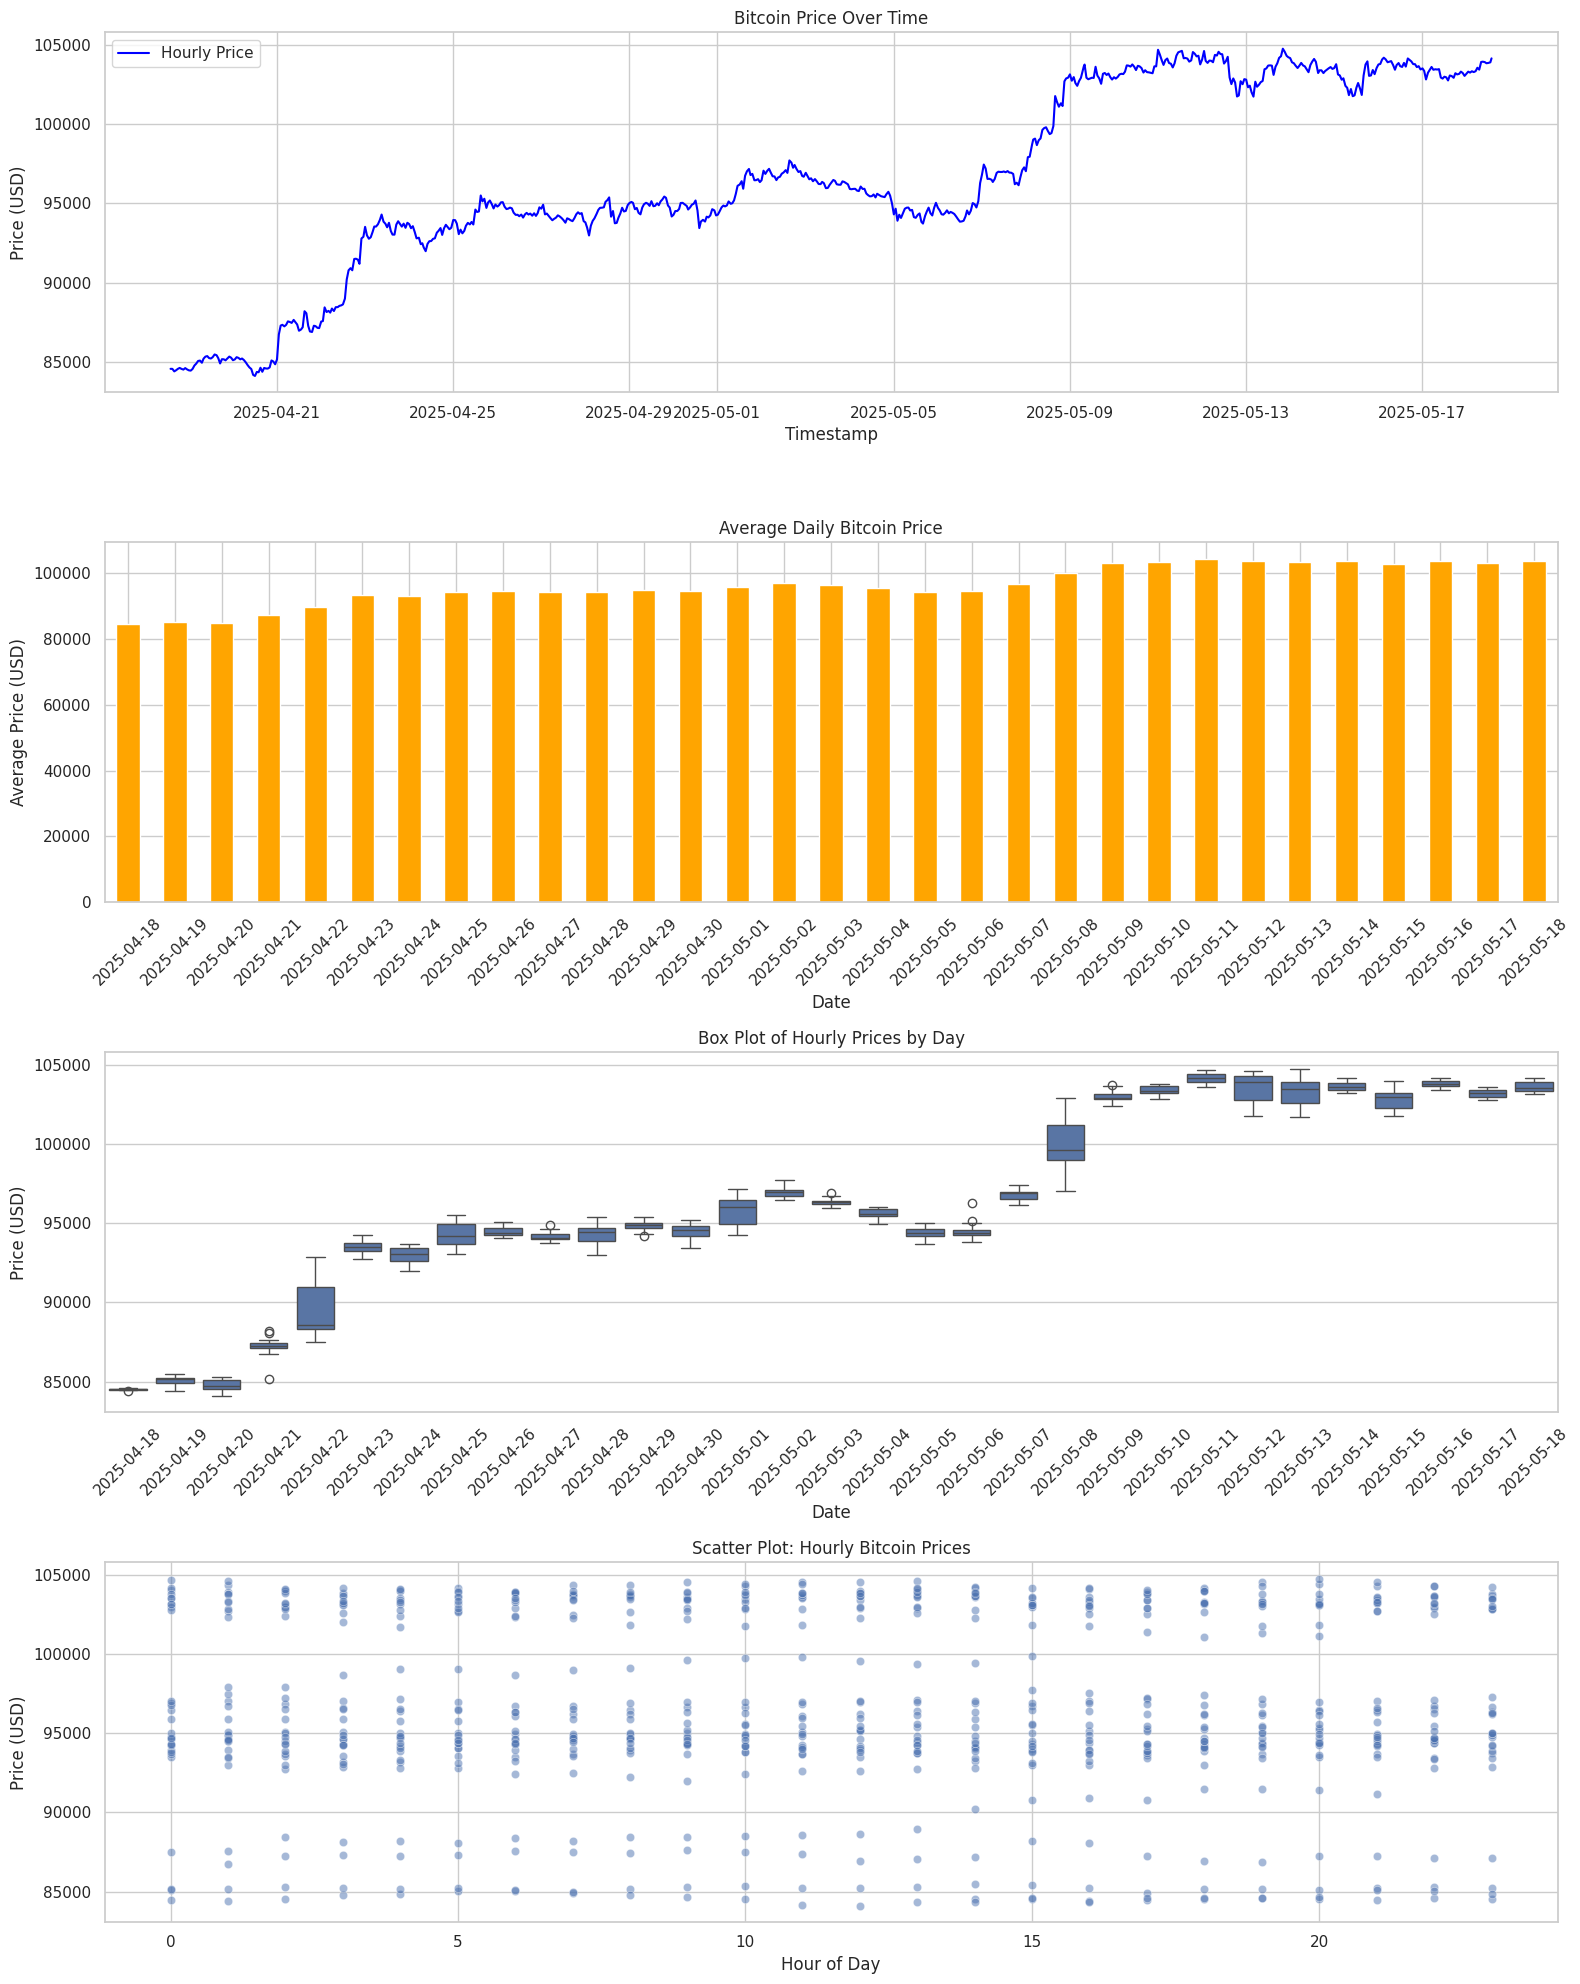

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the historical BTC data
df = pd.read_csv("bitcoin_historical.csv", parse_dates=["timestamp"], index_col="timestamp")

# Ensure the 'price' column is numeric
df["price"] = pd.to_numeric(df["price"], errors='coerce')

# Drop missing values
df = df.dropna()

# Create a new column for day to group by
df["date"] = df.index.date

# Set the plot style
sns.set(style="whitegrid")
plt.figure(figsize=(16, 20))

# 1. Line Plot of Price over Time
plt.subplot(4, 1, 1)
plt.plot(df.index, df["price"], label="Hourly Price", color="blue")
plt.title("Bitcoin Price Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Price (USD)")
plt.legend()

# 2. Bar Plot of Average Daily Price
plt.subplot(4, 1, 2)
daily_avg = df.groupby("date")["price"].mean()
daily_avg.plot(kind="bar", color="orange")
plt.title("Average Daily Bitcoin Price")
plt.xlabel("Date")
plt.ylabel("Average Price (USD)")
plt.xticks(rotation=45)

# 3. Box Plot of Hourly Prices by Day
plt.subplot(4, 1, 3)
sns.boxplot(x="date", y="price", data=df.reset_index())
plt.title("Box Plot of Hourly Prices by Day")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.xticks(rotation=45)

# 4. Scatter Plot: Price vs Time of Day
df["hour"] = df.index.hour
plt.subplot(4, 1, 4)
sns.scatterplot(x="hour", y="price", data=df, alpha=0.5)
plt.title("Scatter Plot: Hourly Bitcoin Prices")
plt.xlabel("Hour of Day")
plt.ylabel("Price (USD)")

plt.tight_layout()
plt.show()


---

# Evaluation Summary

The trained PPO agent was evaluated in a fresh environment using unseen price data. The following results were observed:

- Buy/Sell behavior aligns with profitable segments of the price curve.
- The model prefers to hold during uncertain or flat trends, reflecting a conservative trading bias.
- Cumulative profit increased over time, validating the reward structure and policy learning.

---

## Key Observations

- PPO effectively learned a basic trend-following strategy within limited training timesteps.
- The agent executes profitable sell actions near peaks and avoids overtrading.
- There is no penalty for inactivity, so the model avoids risky trades and holds positions when uncertain.

---

## Limitations

- No transaction costs or slippage modeled.
- Only price data used — no volume, volatility, or technical indicators like RSI/MA.
- Single-agent, single-asset simulation.

---

## Future Enhancements

- Include transaction fees to mimic real-world trading constraints.
- Add more features (RSI, MA, Bollinger Bands) to the observation space.
- Compare PPO with other algorithms like DQN, A2C, SAC.
- Explore multi-agent or multi-asset trading setups.

---

## Conclusion

This notebook demonstrates a full RL pipeline from data ingestion to environment creation, model training, and evaluation — all focused on cryptocurrency market analysis. It is a solid foundation for building intelligent crypto-trading bots using real-time data and reinforcement learning techniques.

---
